# Basic Querying

This beginner-level tutorial loads halo and galaxy catalogs and computes a few basic statistical distributions. 
- halo mass function
- galaxy mass function
- gas fraction

<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Halo Properties</span>
    <span class="chip chip-data">Galaxy Properties</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
    <span class="chip chip-task">Add Columns</span>
  </div>
</div>

First, let's load the relevant libraries. We'll limit ourselves to numpy and matplotlib in addition to the opencosmo library - these will already be in your environment as opencosmo dependencies. 

:::{dropdown} No OpenCosmo installation?
:open: false
If you haven't already installed the OpenCosmo toolkit, you can find install instructions [here](https://opencosmo.readthedocs.io/en/stable/installation.html). This also shows you how to make your OpenCosmo environment available as a Jupyter kernel. 
:::

In [84]:
import opencosmo as oc
import numpy as np
import matplotlib.pyplot as plt

## Inspecting the data

First, let's load a halo catalog, and inspect the fields that are available. 

:::{dropdown} Looking for data?
:open: false

Try the [CosmoExplorer](https://cosmoexplorer.alcf.anl.gov) compute portal, and then come back here to explore it using the toolkit
:::

Loading a catalog is as simple as using 
```python
    dataset = oc.open(path_to_hdf5_file)
```
And then we have access the dataset attributes, including the column names, descriptions, and the simulation cosmology. Importantly we don't have all the data in memory yet. 
```python
    dataset.columns
    dataset.descriptions
    dataset.cosmology    
```
For full details on OpenCosmo datasets take a look at the [dataset API](https://opencosmo.readthedocs.io/en/stable/dataset_ref.html).
For now let's take a look at the columns and see if we can find the right quantities to make some mass functions.

In [85]:
halos = oc.open("haloproperties.hdf5")

for field in halos.columns: 
    if 'mass' in field:
        print(field, ': ', halos.descriptions[field])


fof_halo_mass :  FoF halo mass
sod_halo_mass :  SOD halo mass (200 delta_c definition)
sod_halo_mass_agn :  SOD halo AGN mass (within 200c)
sod_halo_mass_dm :  SOD halo dark matter mass (within 200c)
sod_halo_mass_nHI :  Neutral hydrogen mass of galaxy - (200 delta_c)
sod_halo_mmagn_mass :  Mass of most massive AGN particle (internal mass)
sod_halo_mass_sfgas :  SOD halo star forming gas mass (within 200c)
sod_halo_mass_gas :  SOD halo gas mass (within 200c)
sod_halo_c_acc_mass :  concenctration parameter of SOD halo (accumulative mass definition)
sod_halo_mass_star :  SOD halo star mass (within 200c)
sod_halo_c_peak_mass :  concenctration parameter of SOD halo (peak of dM/dr)
sod_halo_mass_wind :  SOD halo wind mass (within 200c)


:::{dropdown} Be careful with mass definitions!
:open: false

Spherical overdensity algorithms look at properties of all particles in a spherical shell surrounding a center point, while friends-of-friends algorithms directly link dark-matter particles. For hydro simulations, you need to remember that dark-matter FOF algorithms exclude the baryonic mass. 
:::

## Accessing values

Now, let's compute distributions for (1) halo total mass (2) halo gas mass, and (3) halo stellar mass. 

Retrieving the data is easy, simply use 
```python
    data = dataset.get_data()
```
This will return the data along with its (astropy) unit. If we want specific units, we can ask for them with, e.g. 

```python
   data = dataset.with_units("physical").get_data()
```
and if we don't want to load all the data but instead just get specific columns we can select them using 
```python
    data = dataset.select(['list','of','columns'])
```
See [working with units](https://opencosmo.readthedocs.io/en/stable/units.html) and [working with columns](https://opencosmo.readthedocs.io/en/stable/cols.html),  for more. 


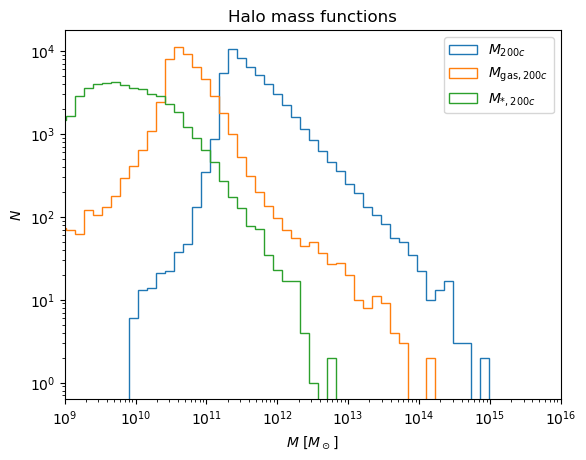

In [86]:
halo_data = halos.select(['sod_halo_mass','sod_halo_mass_gas','sod_halo_mass_star']).with_units("physical").get_data()

hist_bins = np.geomspace(1e8,1e16,64)
plt.hist(halo_data["sod_halo_mass"].value, histtype="step", bins=hist_bins, label=r"$M_{200c}$")
plt.hist(halo_data["sod_halo_mass_gas"].value, histtype="step", bins=hist_bins, label=r"$M_{\text{gas}, 200c}$")
plt.hist(halo_data["sod_halo_mass_star"].value, histtype="step", bins=hist_bins, label=r"$M_{*, 200c}$")

plt.title('Halo mass functions')
plt.xlim(1e9, 1e16)
plt.xlabel(r"$M\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

### Weird tails?

It's important to always apply filters when looking at full sets of simulation halos. In this case what's happening is that spherical overdensity halos are measured at the minimum potential locations of friends-of-friends halos above a certain mass cutoff. But this doesn't truly guarantee that the spherical overdensity halo will be above that mass limit. Let's instead cut halos below the friends-of-friends mass threshold. In this case that is around 

$$
M_{200c} > 9\times 10^{11} M_{\odot},
$$

so we can apply a filter using 

```python
filter_mass = oc.col("sod_halo_mass") > 9e11
halos_filtered = halos.filter(filter_mass)
```


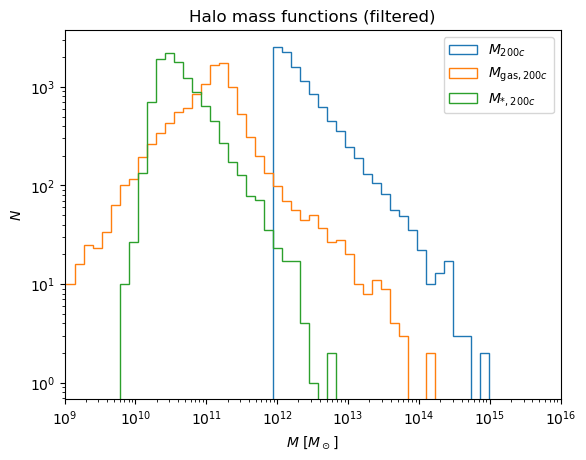

In [87]:

filter_mass = oc.col("sod_halo_mass") > 9e11
halos_filtered = halos.filter(filter_mass)
halo_data = halos_filtered.with_units("physical").get_data()

hist_bins = np.geomspace(1e8,1e16,64)
plt.hist(halo_data["sod_halo_mass"].value, histtype="step", bins=hist_bins, label=r"$M_{200c}$")
plt.hist(halo_data["sod_halo_mass_gas"].value, histtype="step", bins=hist_bins, label=r"$M_{\text{gas}, 200c}$")
plt.hist(halo_data["sod_halo_mass_star"].value, histtype="step", bins=hist_bins, label=r"$M_{*, 200c}$")

plt.title('Halo mass functions (filtered)')
plt.xlim(1e9, 1e16)
plt.xlabel(r"$M\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

## Galaxy data

Now, let's compute a galaxy mass function. For this, we need to load the galaxy catalog:

In [88]:
galaxies = oc.open("galaxyproperties.hdf5")

for field in galaxies.columns: 
    if 'mass' in field:
        print(field, ': ', galaxies.descriptions[field])


gal_mass_sfgas :  star forming gas mass of galaxy (within aperture radius)
gal_mass :  total mass of galaxy (within aperture radius)
gal_2Rhalf_stellar_mass :  stellar mass within 2 * gal_half_stellar_rad
gal_mass_dm :  dark matter mass of galaxy (within aperture radius)
gal_mass_gas :  gas mass of galaxy (within aperture radius)
gal_bulge_stellar_mass :  stellar mass of bulge (estimated from counter-rotating particles, see Weinberger+ 2017)
gal_mmagn_mass :  Mass of most massive AGN particle (internal mass)
gal_mass_star :  stellar mass of galaxy (within aperture radius)
gal_mass_nHI :  Neutral hydrogen mass of galaxy (within aperture radius)
gal_mass_agn :  AGN mass of galaxy (within aperture radius)
gal_mass_bar :  baryon mass of galaxy (within aperture radius)


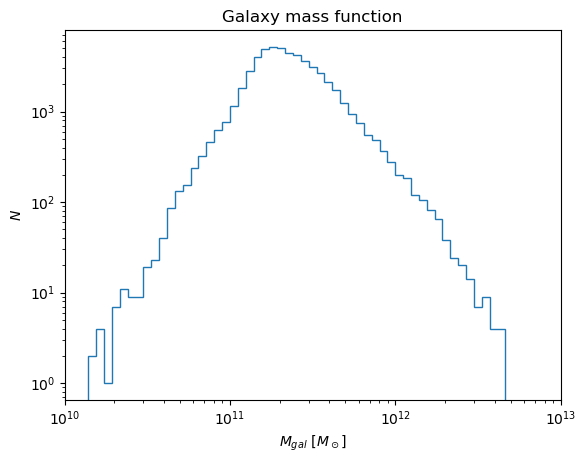

In [89]:
gal_data = galaxies.get_data()

hist_bins = np.geomspace(1e10,1e13,64)
plt.title('Galaxy mass function')
plt.hist(gal_data["gal_mass"].value, histtype="step", bins=hist_bins)
plt.xlim(1e10, 1e13)
plt.xlabel(r"$M_{gal}\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')

plt.show()

## Creating custom fields


What if we wanted to compute a distribution for a custom field that hasn't been defined? 

We can do this using the `with_new_columns` function to insert new columns into the dataset from basic arithmetic of the opencosmo columns. See also [adding custom columns](https://opencosmo.readthedocs.io/en/stable/cols.html#adding-custom-columns). Let's compute halo gas fractions within R200c.

In [94]:
# reload halo catalog
halos = oc.open("haloproperties.hdf5")

sod_halo_fgas = oc.col("sod_halo_mass_gas") / oc.col("sod_halo_mass")

halos = halos.with_new_columns(sod_halo_fgas = sod_halo_fgas)


There is now a new column in the halo properties dataset called "fgas". We can plot it and confirm that if we directly compare `halo_data["sod_halo_mass_gas"]/halo_data["sod_halo_mass"]`, we get the same result as plotting the derived column `"fgas"`

:::{warning} Be careful of fill values!

When SOD halos aren't measured they can be assigned a fill value, typically -101. The fgas for these objects will then be 1 but it won't be an actual measurement! Make sure you filter on mass before doing these computations.  

:::



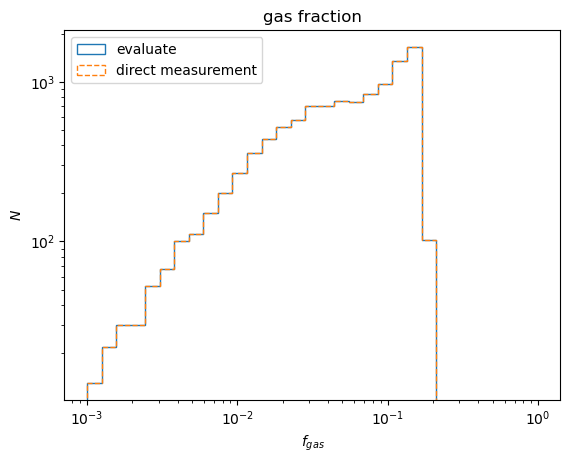

In [95]:
filter_mass = oc.col("sod_halo_mass") > 9e11
halo_data = halos.filter(filter_mass).get_data()

hist_bins = np.geomspace(1e-3, 1e0, 32)
plt.hist(halo_data["sod_halo_fgas"], histtype="step", bins=hist_bins, label='evaluate')
plt.hist(halo_data["sod_halo_mass_gas"]/halo_data["sod_halo_mass"], histtype="step", bins=hist_bins, linestyle='--', label='direct measurement')
plt.title('gas fraction')
plt.xlabel(r"$f_{gas}$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()

### Using new columns

The benefit of using new columns is not typically to create easier plots, but to be able to now filter the read-in on those directly and get new population sub-samples without reading the whole data set. As an example let's look at the halo mass functions restricting to halos with a gas fraction above 10\%. 



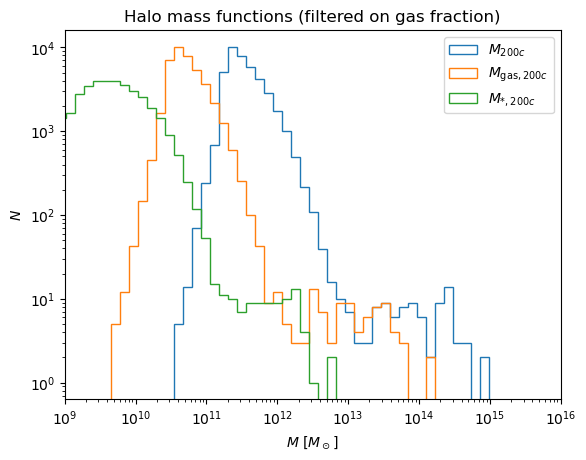

In [96]:

filter_gf = oc.col("sod_halo_fgas") > 1.e-1
halos_filtered = halos.filter(filter_gf)

halo_data = halos_filtered.with_units("physical").get_data()
hist_bins = np.geomspace(1e8,1e16,64)
plt.hist(halo_data["sod_halo_mass"].value, histtype="step", bins=hist_bins, label=r"$M_{200c}$")
plt.hist(halo_data["sod_halo_mass_gas"].value, histtype="step", bins=hist_bins, label=r"$M_{\text{gas}, 200c}$")
plt.hist(halo_data["sod_halo_mass_star"].value, histtype="step", bins=hist_bins, label=r"$M_{*, 200c}$")

plt.title('Halo mass functions (filtered on gas fraction)')
plt.xlim(1e9, 1e16)
plt.xlabel(r"$M\,\,[M_\odot]$")
plt.ylabel(r"$N$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

plt.show()